# APKVC Distortion Analysis

This notebook demonstrates how to track and visualize the distortion introduced by the **Attention-Aware Predictive KV** (APKVC) cache compression mechanism.

### Why analyze distortion?
APKVC uses a key-dot product distortion proxy to decide when the compression error is too high, at which point it resets to a full "anchor" token. Higher distortion levels correlate with accuracy drops in long-context tasks.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from attention_aware_predictive_kv import AttentionAwarePredictiveKVCluster
from commonkv.viz_utils import plot_distortion_distributions, plot_distortion_timeline, get_cluster_stats

## 1. Setup Simulation
We will run a dummy sequence through the APKVC cluster to collect some distortion data.

In [2]:
# Initialize a cluster with a low threshold to trigger more resets
cluster = AttentionAwarePredictiveKVCluster(
    predictor_type='linear',
    rd_threshold=0.05,
    max_anchor_interval=16,
    K_num_codebooks=4,
    V_num_codebooks=2
)

bsz, num_heads, head_dim = 1, 32, 128
seq_len = 100

# 1. Prefill
q_prefill = torch.randn(bsz, num_heads, 10, head_dim)
k_prefill = torch.randn(bsz, num_heads, 10, head_dim)
v_prefill = torch.randn(bsz, num_heads, 10, head_dim)
cluster.update_kv(k_prefill, q_prefill, v_prefill, None, 1)

# 2. Decoding Steps
for i in range(seq_len):
    q_i = torch.randn(bsz, num_heads, 1, head_dim)
    k_i = torch.randn(bsz, num_heads, 1, head_dim) + (0.1 * torch.randn(bsz, num_heads, 1, head_dim)) # add some drift
    v_i = torch.randn(bsz, num_heads, 1, head_dim)
    cluster.update_kv(k_i, q_i, v_i, None, 1)

print(f"Produced {len(cluster.distortion_history)} steps of data.")

Produced 110 steps of data.


## 2. Visualization

### Distortion Distribution
This histogram shows the spread of distortion across the sequence. Values close to 0 are more accurate.

/home/seqaeon/Downloads/CommonKV/commonkv/viz_utils.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


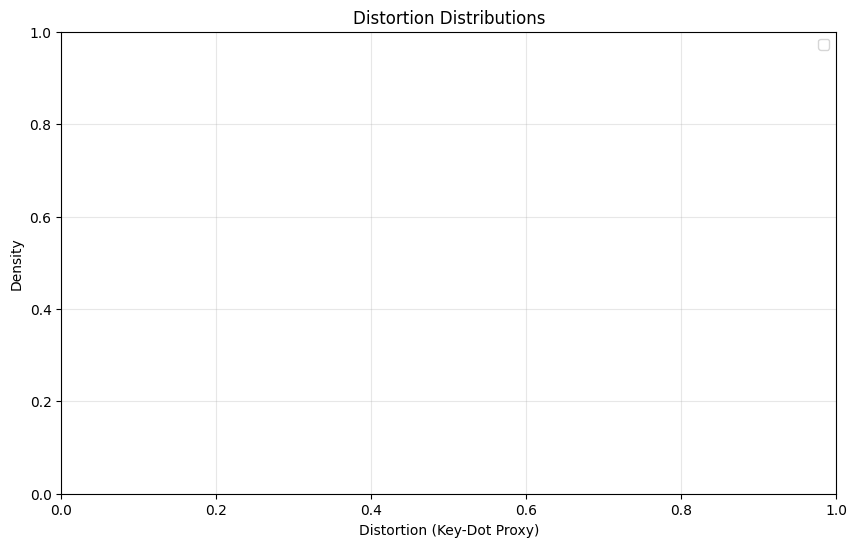

In [3]:
plot_distortion_distributions([cluster], layer_names=["Mock Layer 0"])

### Distortion over Time
The timeline shows how distortion grows between anchors. Marked 'x' at the bottom indicate anchor points (resets).

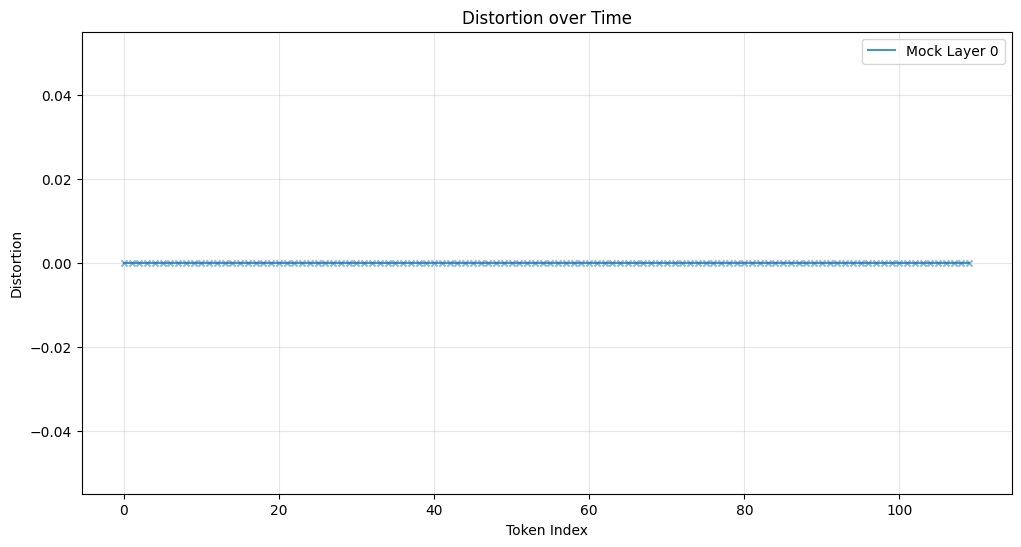

In [4]:
plot_distortion_timeline([cluster], layer_names=["Mock Layer 0"])

## 3. Summary Statistics
Calculate the compression efficiency and average error.

In [5]:
stats = get_cluster_stats(cluster)
for k, v in stats.items():
    print(f"{k:20s}: {v:.4f}")

count               : 0.0000
mean                : 0.0000
max                 : 0.0000
anchors             : 110.0000
